# MRI H5 Patient and Study Description Statistics

This notebook extracts and summarizes statistics based only on `patientID` and `tStudyDescription` from MRI HDF5 (H5) files.

In [1]:
import os
import h5py
import numpy as np
from pathlib import Path
import xml.dom.minidom as minidom
from collections import Counter
from tabulate import tabulate
import matplotlib as mpl

# Set data folder path
home_folder = os.path.expanduser("~")
parent_folder = os.path.abspath(os.path.join(home_folder, "..", ".."))
data_folder = Path(parent_folder) / 'data/datasets/msk_mri_h5/h5'

h5_paths = sorted(
    p for p in data_folder.iterdir()
    if p.suffix.lower() in {'.h5', '.hdf5'} and p.is_file()
    )
print(f'Found {len(h5_paths)} H5 files in: {data_folder}')

def _first_text_from_tag(parent_node, tag_name):
    nodes = parent_node.getElementsByTagName(tag_name)
    if nodes:
        for node in nodes[0].childNodes:
            if node.nodeType == node.TEXT_NODE:
                text = node.data.strip()
                if text:
                    return text
    return None

def read_xml_from_h5(h5_path: Path):
    try:
        with h5py.File(h5_path, 'r') as f:
            dataset = f.get('dataset')
            if dataset is not None and 'xml' in dataset:
                raw = dataset['xml'][0]
                if isinstance(raw, (bytes, bytearray)):
                    return raw.decode('utf-8', errors='ignore')
                return str(raw)
    except Exception:
        pass
    return None

def parse_xml_fields(xml_str: str):
    parsed = {
        'patientID': None,
        'tStudyDescription': None,
        'sliceCount': None,
    }
    try:
        doc = minidom.parseString(xml_str)
    except Exception:
        return parsed

    subj_nodes = doc.getElementsByTagName('subjectInformation')
    if subj_nodes:
        parsed['patientID'] = _first_text_from_tag(subj_nodes[0], 'patientID')

    for up in doc.getElementsByTagName('userParameterString'):
        name = _first_text_from_tag(up, 'name')
        value = _first_text_from_tag(up, 'value')
        if name == 'tStudyDescription':
            parsed['tStudyDescription'] = value

    # Extract sliceCount from encodingLimits/slice/maximum in XML
    try:
        encoding_limits = doc.getElementsByTagName('encodingLimits')
        if encoding_limits:
            slice_nodes = encoding_limits[0].getElementsByTagName('slice')
            if slice_nodes:
                max_nodes = slice_nodes[0].getElementsByTagName('maximum')
                if max_nodes and max_nodes[0].firstChild:
                    max_val = max_nodes[0].firstChild.data.strip()
                    if max_val.isdigit():
                        parsed['sliceCount'] = int(max_val) + 1
    except Exception:
        pass

    return parsed

# Build a dictionary with tStudyDescription, patientID, filename, and slice_count
records = []
total_slices = 0
for path in h5_paths:
    xml_str = read_xml_from_h5(path)
    if not xml_str:
        continue
    parsed = parse_xml_fields(xml_str)
    if parsed['patientID'] and parsed['tStudyDescription'] and parsed['sliceCount'] is not None:
        slice_count = parsed['sliceCount']
        total_slices += slice_count
        records.append({
            'patientID': parsed['patientID'],
            'tStudyDescription': parsed['tStudyDescription'],
            'fname': path.name,
            'slice_count': slice_count
        })

print(f'Total valid records: {len(records)}')
print(f'Total slices across all records: {total_slices}')

Found 2376 H5 files in: /data/datasets/msk_mri_h5/h5
Total valid records: 2372
Total slices across all records: 71001


In [2]:
# Match tStudyDescription to scan_categories, print unmatched, and patient count after filtering
scan_categories = {
    "SPINE": {
        "includes": [
            "L-SPINE", "LSPINE", "L SPINE",
            "C-SPINE", "CSPINE", "C SPINE",
            "T-SPINE", "T SPINE",
            "AX T2 T-SP", "AX T2 T-SP WARP"
        ]
    },
    "KNEE": {
        "includes": ["LT KNEE", "RT KNEE"]
    },
    "SHOULDER": {
        "includes": ["LT SHOULDER", "RT SHOULDER"]
    },
    "HIP": {
        "includes": ["LT HIP", "RT HIP"]
    },
    "ANKLE": {
        "includes": ["LT ANKLE", "RT ANKLE"]
    },
    "FOOT": {
        "includes": ["LT FOOT", "RT FOOT"]
    },
    "LEG_TIBFIB": {
        "includes": ["LT LEG", "RT TIB-FIB"]
    },
    "ELBOW": {
        "includes": ["LT ELBOW", "RT ELBOW"]
    },
    "WRIST_HAND_THUMB": {
        "includes": ["LT WRIST", "RT WRIST", "LT THUMB", "RT THUMB", "RT HAND", "WRIST RT"]
    },
    "PELVIS_PUBALGIA": {
        "includes": ["PELVIS", "ATH PUBALGIA"]
    },
    "SCAPULA_RIBS_FEMUR": {
        "includes": ["RT SCAPULA", "RIBS", "LT FEMUR"]
    }
}

# Print number of unique patients before filtering
all_patient_ids = set(rec['patientID'] for rec in records)
print(f'Number of unique patients before scan category filtering: {len(all_patient_ids)}')

desc_to_category = {}
for cat, info in scan_categories.items():
    for inc in info['includes']:
        desc_to_category[inc] = cat

matched_records = []
unmatched_records = []
for rec in records:
    desc = rec['tStudyDescription']
    matched = False
    for inc, cat in desc_to_category.items():
        if inc in desc:
            rec['category'] = cat
            matched_records.append(rec)
            matched = True
            break
    if not matched:
        unmatched_records.append(rec)

print(f'Number of matched records: {len(matched_records)}')
print(f'Number of unmatched records: {len(unmatched_records)}')

# Print number of unique patients after filtering by scan categories
filtered_patient_ids = set(rec['patientID'] for rec in matched_records)
print(f'Number of unique patients after scan category filtering: {len(filtered_patient_ids)}')

# Print the amount of files and patients per scan category as a table
# Compute file and patient counts per scan category
cat_file_counts = {cat: 0 for cat in scan_categories}
cat_patient_ids = {cat: set() for cat in scan_categories}
for rec in matched_records:
    cat = rec['category']
    cat_file_counts[cat] += 1
    cat_patient_ids[cat].add(rec['patientID'])
    
table = []
for cat in scan_categories.keys():
    table.append([cat, cat_file_counts[cat], len(cat_patient_ids[cat])])
print('\nFiles and unique patients per scan category:')
print(tabulate(table, headers=["Category", "Files", "Unique Patients"], tablefmt="github"))



if unmatched_records:
    print('\nUnique unmatched tStudyDescriptions:')
    unique_unmatched = sorted(set(rec['tStudyDescription'] for rec in unmatched_records))
    for desc in unique_unmatched:
        print(f"  {desc}")

all_patients = set(rec['patientID'] for rec in matched_records)

Number of unique patients before scan category filtering: 425
Number of matched records: 2372
Number of unmatched records: 0
Number of unique patients after scan category filtering: 425

Files and unique patients per scan category:
| Category           |   Files |   Unique Patients |
|--------------------|---------|-------------------|
| SPINE              |    1100 |               188 |
| KNEE               |     330 |                69 |
| SHOULDER           |     324 |                60 |
| HIP                |     201 |                44 |
| ANKLE              |     129 |                25 |
| FOOT               |      84 |                13 |
| LEG_TIBFIB         |      29 |                 3 |
| ELBOW              |      47 |                10 |
| WRIST_HAND_THUMB   |      73 |                14 |
| PELVIS_PUBALGIA    |      40 |                 8 |
| SCAPULA_RIBS_FEMUR |      15 |                 4 |


In [3]:
import random
from collections import defaultdict, Counter
from math import inf

def split_by_patients(
    matched_records,
    ratios={'train':0.70, 'val':0.15, 'test':0.15},
    seed=20,
    max_passes=10,
    max_local_iters=3000,
    weights=None,
):
    """
    Patient-level multi-objective split that approximates:
      - per-class slice ratios (70/15/15),
      - global slice ratios,
      - #files and #patients ratios,
    while forbidding patient overlap across splits.

    Args:
      matched_records: list of dicts with keys
        ['patientID','tStudyDescription','fname','slice_count','category']
      weights: dict of objective weights:
        {
          'class_slices': 1.0,     # per-class slice ratio error
          'global_slices': 0.6,    # global slice ratio error
          'files': 0.25,           # file count ratio error
          'patients': 0.25,        # patient count ratio error
          'class_coverage': 0.15,  # reward coverage (avoid zero per-split class)
        }
    Returns:
      split_records: {'train': [...], 'val': [...], 'test': [...]}
      summary: dict with final stats and per-split/per-class tallies
    """

    if weights is None:
        weights = {
            'class_slices': 1.0,
            'global_slices': 0.6,
            'files': 0.25,
            'patients': 0.25,
            'class_coverage': 0.15,
        }

    rng = random.Random(seed)

    # ----------------------------
    # 1) Aggregate at patient level
    # ----------------------------
    patients = defaultdict(list)
    for r in matched_records:
        patients[r['patientID']].append(r)

    patient_ids = list(patients.keys())

    # Per-patient stats
    pid_total_slices = {}
    pid_files = {}
    pid_class_slices = {}
    all_classes = set()

    for pid, recs in patients.items():
        pid_total_slices[pid] = sum(r['slice_count'] for r in recs)
        pid_files[pid] = len(recs)
        class_map = defaultdict(int)
        for r in recs:
            c = r['category']
            class_map[c] += r['slice_count']
            all_classes.add(c)
        pid_class_slices[pid] = dict(class_map)

    all_classes = sorted(all_classes)

    # Global targets
    total_slices_global = sum(pid_total_slices.values())
    total_files_global = sum(pid_files.values())
    total_patients_global = len(patient_ids)

    split_names = ['train','val','test']
    # Targets for slices/files/patients
    target_global_slices = {s: round(total_slices_global*ratios[s]) for s in split_names}
    target_files = {s: round(total_files_global*ratios[s]) for s in split_names}
    target_patients = {s: round(total_patients_global*ratios[s]) for s in split_names}

    # Per-class slice targets
    class_totals = {c:0 for c in all_classes}
    for pid in patient_ids:
        for c, sc in pid_class_slices[pid].items():
            class_totals[c] += sc
    target_class_slices = {
        c: {s: round(class_totals[c]*ratios[s]) for s in split_names}
        for c in all_classes
    }

    # Current tallies
    split_counts = {
        s: {
            'slices': 0,
            'files': 0,
            'patients': 0,
            'class_slices': {c:0 for c in all_classes}
        } for s in split_names
    }

    def add_pid_to_split(pid, s):
        split_counts[s]['slices'] += pid_total_slices[pid]
        split_counts[s]['files']  += pid_files[pid]
        split_counts[s]['patients'] += 1
        for c, sc in pid_class_slices[pid].items():
            split_counts[s]['class_slices'][c] += sc

    def remove_pid_from_split(pid, s):
        split_counts[s]['slices'] -= pid_total_slices[pid]
        split_counts[s]['files']  -= pid_files[pid]
        split_counts[s]['patients'] -= 1
        for c, sc in pid_class_slices[pid].items():
            split_counts[s]['class_slices'][c] -= sc

    def objective():
        # normalized absolute errors against targets
        eps = 1e-9
        # Per-class slice error
        class_err = 0.0
        denom_class = 0.0
        for c in all_classes:
            denom_class += class_totals[c] + eps
            for s in split_names:
                tgt = target_class_slices[c][s]
                cur = split_counts[s]['class_slices'][c]
                class_err += abs(cur - tgt)

        class_err /= (denom_class)

        # Global slice error
        glob_err = 0.0
        for s in split_names:
            glob_err += abs(split_counts[s]['slices'] - target_global_slices[s])
        glob_err /= (total_slices_global + eps)

        # Files error
        files_err = 0.0
        for s in split_names:
            files_err += abs(split_counts[s]['files'] - target_files[s])
        files_err /= (total_files_global + eps)

        # Patients error
        pat_err = 0.0
        for s in split_names:
            pat_err += abs(split_counts[s]['patients'] - target_patients[s])
        pat_err /= (total_patients_global + eps)

        # Class coverage bonus: reward distributions where each class appears in each split
        # (equivalent to a penalty if a class is missing in a split)
        coverage_pen = 0.0
        want_coverage = 0
        missing = 0
        for c in all_classes:
            for s in split_names:
                want_coverage += 1
                if split_counts[s]['class_slices'][c] == 0 and class_totals[c] > 0:
                    missing += 1
        if want_coverage > 0:
            coverage_pen = missing / want_coverage  # 0 (best) to 1 (worst)

        return (
            weights['class_slices'] * class_err +
            weights['global_slices'] * glob_err +
            weights['files'] * files_err +
            weights['patients'] * pat_err +
            weights['class_coverage'] * coverage_pen
        )

    # ----------------------------
    # 3) Initialization (greedy)
    #    Sort patients by total slices desc and place where they reduce loss most
    # ----------------------------
    assignment = {}
    sorted_pids = sorted(patient_ids, key=lambda p: (-pid_total_slices[p], -pid_files[p]))

    # Start empty
    best_loss = None
    for pid in sorted_pids:
        best_s = None
        best_delta = inf
        # Try each split, pick best improvement
        baseline = objective() if best_loss is not None else None
        # When empty, just compare absolute loss after adding patient
        for s in split_names:
            add_pid_to_split(pid, s)
            loss = objective()
            remove_pid_from_split(pid, s)
            delta = loss if baseline is None else loss - baseline
            if delta < best_delta:
                best_delta = delta
                best_s = s
        assignment[pid] = best_s
        add_pid_to_split(pid, best_s)
        best_loss = objective()

    # ----------------------------
    # 4) Local search: random swaps & moves
    # ----------------------------
    def try_move(pid, from_s, to_s):
        if from_s == to_s: 
            return False
        old = objective()
        remove_pid_from_split(pid, from_s)
        add_pid_to_split(pid, to_s)
        new = objective()
        if new + 1e-12 < old:
            assignment[pid] = to_s
            return True
        # revert
        remove_pid_from_split(pid, to_s)
        add_pid_to_split(pid, from_s)
        return False

    def try_swap(pid_a, pid_b):
        sa = assignment[pid_a]
        sb = assignment[pid_b]
        if sa == sb: 
            return False
        old = objective()
        # swap a->sb, b->sa
        remove_pid_from_split(pid_a, sa)
        remove_pid_from_split(pid_b, sb)
        add_pid_to_split(pid_a, sb)
        add_pid_to_split(pid_b, sa)
        new = objective()
        if new + 1e-12 < old:
            assignment[pid_a], assignment[pid_b] = sb, sa
            return True
        # revert
        remove_pid_from_split(pid_a, sb)
        remove_pid_from_split(pid_b, sa)
        add_pid_to_split(pid_a, sa)
        add_pid_to_split(pid_b, sb)
        return False

    pids_vec = list(patient_ids)
    for _ in range(max_passes):
        improved = False

        # random single moves
        for _ in range(max_local_iters // 2):
            pid = rng.choice(pids_vec)
            from_s = assignment[pid]
            to_s = rng.choice(split_names)
            if try_move(pid, from_s, to_s):
                improved = True

        # random pair swaps
        for _ in range(max_local_iters // 2):
            a, b = rng.sample(pids_vec, 2)
            if try_swap(a, b):
                improved = True

        if not improved:
            break

    # ----------------------------
    # 5) Build output
    # ----------------------------
    split_records = {s: [] for s in split_names}
    for pid, s in assignment.items():
        split_records[s].extend(patients[pid])

    return split_records


# ----------------------------
# Example usage
# ----------------------------
split_records = split_by_patients(matched_records)


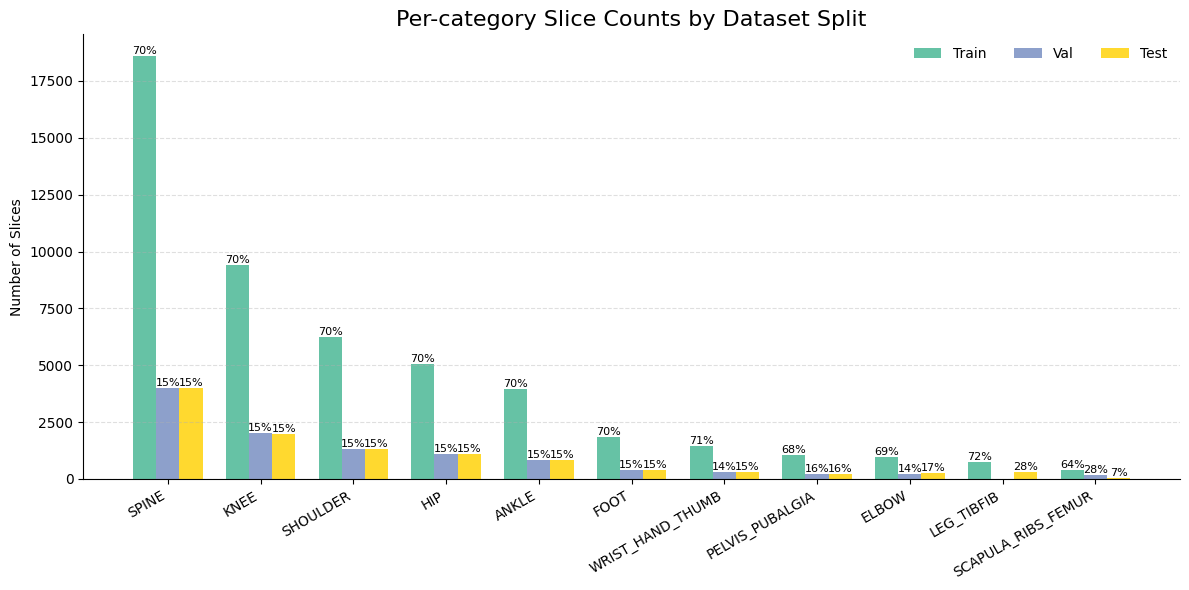

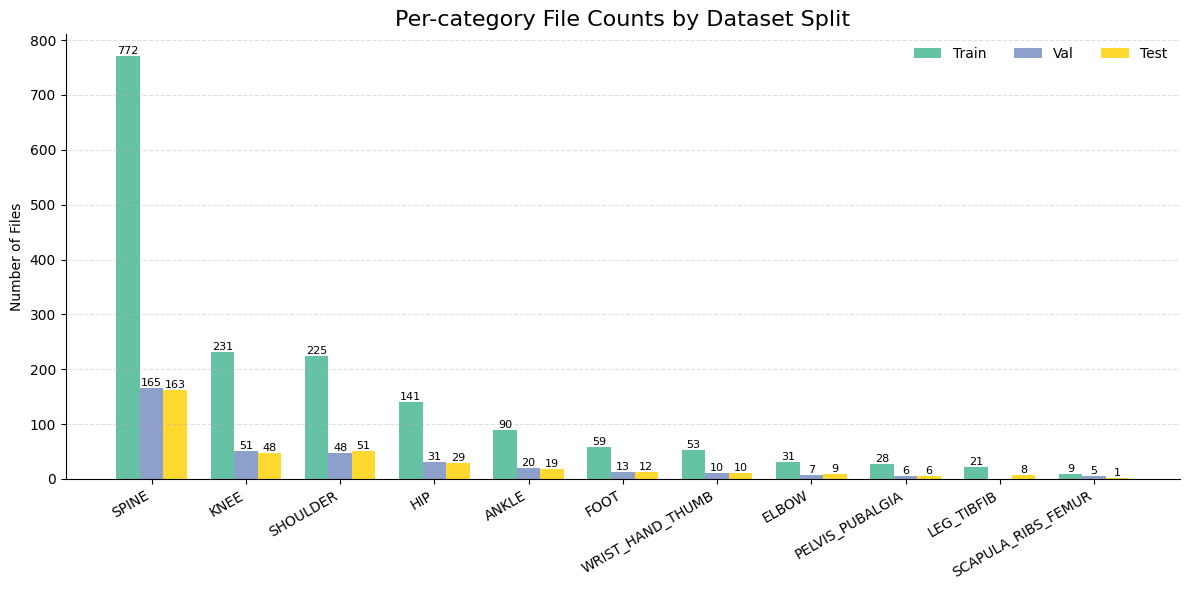

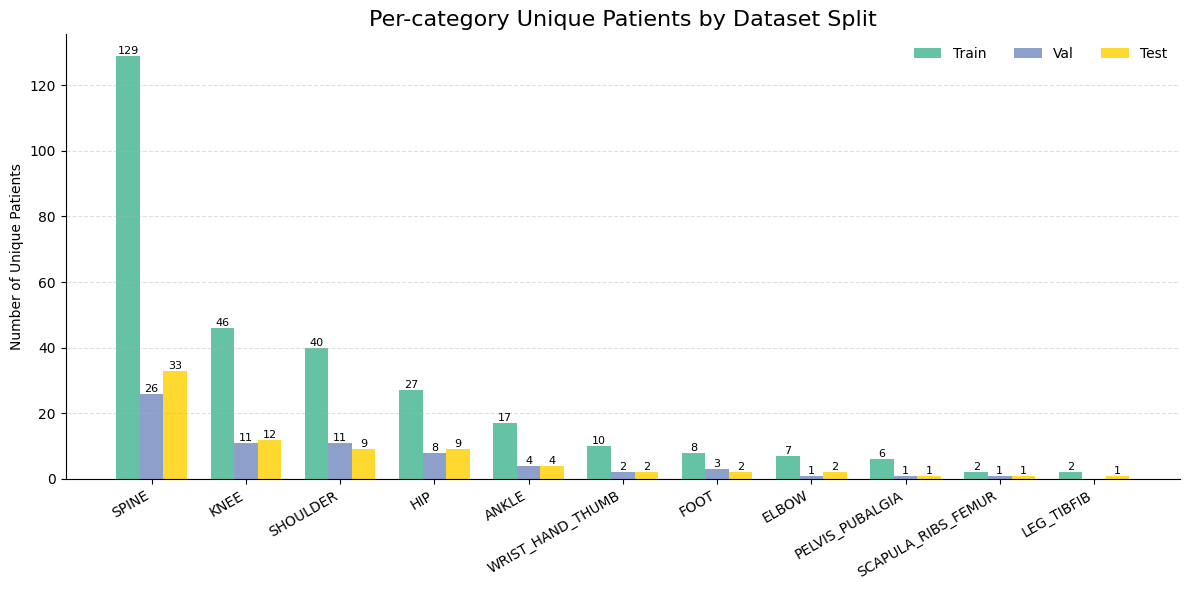

In [4]:
import matplotlib.pyplot as plt
from collections import defaultdict

import matplotlib.pyplot as plt
from collections import defaultdict
import matplotlib as mpl

def plot_per_category_stats(split_records, mode="slices"):
    """
    Build a grouped bar chart (Train/Val/Test) per category for:
        - mode="slices"   → total slice counts (with % labels)
        - mode="patients" → unique patients per category
        - mode="files"    → total files per category

    Expects split_records = {'train': [...], 'val': [...], 'test': [...]}
    Each record needs fields: 'category', 'slice_count', 'patientID'.
    """
    assert mode in ["slices", "patients", "files"], "mode must be 'slices', 'patients', or 'files'"
    splits = ['train', 'val', 'test']

    # 1) Aggregate metrics per (split, category)
    per_split_cat = {s: defaultdict(int) for s in splits}

    if mode == "slices":
        for s in splits:
            for r in split_records[s]:
                per_split_cat[s][r['category']] += int(r['slice_count'])

    elif mode == "files":
        for s in splits:
            for r in split_records[s]:
                per_split_cat[s][r['category']] += 1

    elif mode == "patients":
        # unique patients per category per split
        per_split_patients = {s: defaultdict(set) for s in splits}
        for s in splits:
            for r in split_records[s]:
                per_split_patients[s][r['category']].add(r['patientID'])
        for s in splits:
            for cat, pset in per_split_patients[s].items():
                per_split_cat[s][cat] = len(pset)

    # 2) Determine all categories and order by total values
    all_categories = sorted(
        set().union(*[set(per_split_cat[s].keys()) for s in splits])
    )
    totals_per_cat = {
        c: sum(per_split_cat[s].get(c, 0) for s in splits)
        for c in all_categories
    }
    categories = sorted(all_categories, key=lambda c: totals_per_cat[c], reverse=True)

    # 3) Prepare y-values and percentages aligned to categories
    y = {s: [per_split_cat[s].get(c, 0) for c in categories] for s in splits}
    total = [totals_per_cat[c] for c in categories]
    pct = {
        s: [
            (y[s][i] / total[i] * 100.0) if total[i] > 0 else 0.0
            for i in range(len(categories))
        ]
        for s in splits
    }
    counts = {s: y[s] for s in splits}

    # 4) Plot
    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(categories))
    bw = 0.25  # bar width
    offsets = {'train': -bw, 'val': 0.0, 'test': bw}
    bars = {}

    colors = mpl.colormaps['Set2']
    for s in splits:
        bars[s] = ax.bar(
            [xi + offsets[s] for xi in x],
            y[s],
            width=bw,
            color=colors(splits.index(s) / len(splits)),
            label=s.capitalize()
        )

    # 5) Percent labels (only for slice plot, to avoid clutter)
    if mode == "slices":
        def _annotate(bar_container, percentages):
            for rect, p in zip(bar_container, percentages):
                height = rect.get_height()
                if height > 0:
                    ax.text(
                        rect.get_x() + rect.get_width() / 2.0,
                        height,
                        f"{round(p)}%",
                        ha='center', va='bottom', fontsize=8
                    )
        for s in splits:
            _annotate(bars[s], pct[s])
    elif mode in ["patients", "files"]:
        def _annotate(bar_container, counts):
            for rect, count in zip(bar_container, counts):
                height = rect.get_height()
                if height > 0:
                    ax.text(
                        rect.get_x() + rect.get_width() / 2.0,
                        height,
                        f"{count}",
                        ha='center', va='bottom', fontsize=8
                    )
        for s in splits:
            _annotate(bars[s], counts[s])

    # 6) Cosmetics
    title_map = {
        "slices": "Per-category Slice Counts by Dataset Split",
        "patients": "Per-category Unique Patients by Dataset Split",
        "files": "Per-category File Counts by Dataset Split"
    }
    ylabel_map = {
        "slices": "Number of Slices",
        "patients": "Number of Unique Patients",
        "files": "Number of Files"
    }

    ax.set_title(title_map[mode], fontsize=16)
    ax.set_ylabel(ylabel_map[mode])
    ax.set_xticks(list(x))
    ax.set_xticklabels(categories, rotation=30, ha='right')
    ax.legend(title=None, ncols=3, frameon=False)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.xaxis.grid(False)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    plt.show()

# Slices per category (with % labels)
plot_per_category_stats(split_records, mode="slices")

# Files per category
plot_per_category_stats(split_records, mode="files")

# Patients per category
plot_per_category_stats(split_records, mode="patients")



In [5]:
print("=== Dataset Split Statistics ===")
total_patients = 0
total_slices = 0

for split, records in split_records.items():
    num_files = len(records)
    unique_patients = {r['patientID'] for r in records}
    num_patients = len(unique_patients)
    num_slices = sum(int(r['slice_count']) for r in records)

    total_patients += num_patients
    total_slices += num_slices

    print(f"{split.upper():<6} → {num_files:>5} files | "
            f"{num_patients:>4} unique patients | "
            f"{num_slices:>7} slices")

print("\n=== Consistency Checks ===")
print(f"All patients accounted for?  {total_patients == len(all_patients)} "
        f"({total_patients}/{len(all_patients)})")
print(f"All files accounted for?     {sum(len(v) for v in split_records.values()) == len(matched_records)} "
        f"({sum(len(v) for v in split_records.values())}/{len(matched_records)})")
print(f"Total slices (sum across splits): {total_slices:,}")

=== Dataset Split Statistics ===
TRAIN  →  1660 files |  286 unique patients |   49667 slices
VAL    →   356 files |   64 unique patients |   10580 slices
TEST   →   356 files |   75 unique patients |   10754 slices

=== Consistency Checks ===
All patients accounted for?  True (425/425)
All files accounted for?     True (2372/2372)
Total slices (sum across splits): 71,001


# Move train/val/test files to new folders (move, not copy)

In [7]:
import shutil
from pathlib import Path

# Set source and destination root folders
home_folder = os.path.expanduser("~")
parent_folder = os.path.abspath(os.path.join(home_folder, "..", ".."))
output_root = Path(parent_folder) / 'data/datasets/msk_mri_h5'
source_folder = Path(parent_folder) / 'data/datasets/msk_mri_h5/varnet_mrpro'
output_root.mkdir(exist_ok=True)

for split in ['train', 'val', 'test']:
    split_folder = output_root / ("varnet_msk_dataset3/multicoil_" + split)
    split_folder.mkdir(exist_ok=True)
    for rec in split_records[split]:
        src = source_folder / rec['fname']
        dst = split_folder / rec['fname']
        if not dst.exists():
            try:
                shutil.move(str(src), str(dst))
            except Exception as e:
                print(f"Failed to move {src} to {dst}: {e}")
print(f"Files moved to {output_root}/[train|val|test]/")

Failed to move /data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00260_FID112237_COR_STIR.h5 to /data/datasets/msk_mri_h5/varnet_msk_dataset3/multicoil_train/meas_MID00260_FID112237_COR_STIR.h5: [Errno 2] No such file or directory: '/data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00260_FID112237_COR_STIR.h5'
Failed to move /data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00265_FID112242_COR_T1.h5 to /data/datasets/msk_mri_h5/varnet_msk_dataset3/multicoil_train/meas_MID00265_FID112242_COR_T1.h5: [Errno 2] No such file or directory: '/data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00265_FID112242_COR_T1.h5'
Failed to move /data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00213_FID123579_SAG_T1.h5 to /data/datasets/msk_mri_h5/varnet_msk_dataset3/multicoil_train/meas_MID00213_FID123579_SAG_T1.h5: [Errno 2] No such file or directory: '/data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00213_FID123579_SAG_T1.h5'
Failed to move /data/datasets/msk_mri_h5/varnet_mrpro/meas_MID00265_FID110698_SAG_PD.h5 to /da

# Move train/val/test files back to the original h5 folder (undo split move)

In [1]:
import shutil
from pathlib import Path
import os
# Set source and destination root folders
home_folder = os.path.expanduser("~")
parent_folder = os.path.abspath(os.path.join(home_folder, "..", ".."))
output_root = Path(parent_folder) / 'data/datasets/msk_mri_h5'
h5_folder = output_root / 'varnet_mrpro'
h5_folder.mkdir(exist_ok=True)

for split in ['varnet_msk_dataset/multicoil_train', 'varnet_msk_dataset/multicoil_val', 'varnet_msk_dataset/multicoil_test']:
    split_folder = output_root / split
    if not split_folder.exists():
        continue
    for file in split_folder.glob('*.h5'):
        dst = h5_folder / file.name
        if not dst.exists():
            try:
                shutil.move(str(file), str(dst))
            except Exception as e:
                print(f"Failed to move {file} to {dst}: {e}")
print(f"Files moved back to {h5_folder}/")

Files moved back to /data/datasets/msk_mri_h5/varnet_mrpro/
